Now we will work on the exploratory data analysis for this recently cleaned dataset.  Let's download the dataset and install the required libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('matches_complete6.0.csv')

We need to change the WinningTeam Column so that it outputs 1 if Team A wins and 0 if Team B wins.  This makes it so that any machine learning model we make will be able to predict the outcome of matches.

In [2]:
df['Target'] = df['WinningTeam'].apply(lambda x: 1 if x == 'TeamA' else 0)
df['Favored_Won'] = np.where(((df['DUPR_Diff'] > 0) & (df['Target'] == 1)) |
                             ((df['DUPR_Diff'] < 0) & (df['Target'] == 0)), 1, 0)

Let's look at how this code tests the DUPR score in pickleball matches. We want to see if a difference in player ratings predicts match outcomes.  This code calculates the absolute difference in ratings between the two teams, sorts every match into five size brackets, groups the matches by these brackets, and calculates the win percentage for the statistically favored team inside each bracket.  This histogram shows how the favored team actually tends to lose more often than not.

/tmp/ipython-input-4148245772.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=win_rates, x='Skill_Gap_Bin', y='Win_Rate', palette='viridis')


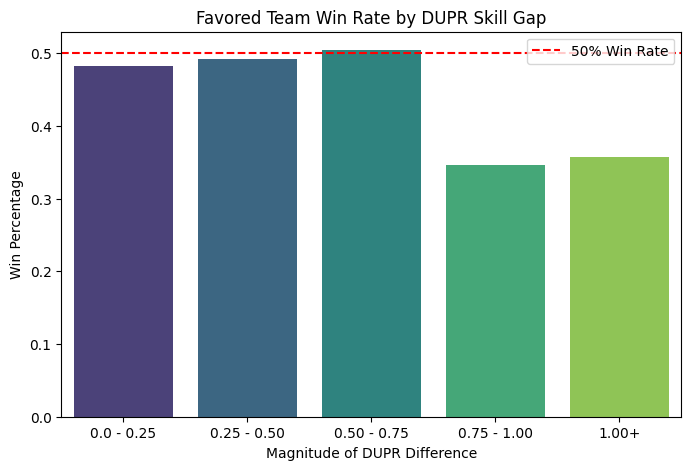

In [3]:
df['DUPR_Gap_Magnitude'] = df['DUPR_Diff'].abs()
bins = [0, 0.25, 0.5, 0.75, 1.0, 5.0]
labels = ['0.0 - 0.25', '0.25 - 0.50', '0.50 - 0.75', '0.75 - 1.00', '1.00+']
df['Skill_Gap_Bin'] = pd.cut(df['DUPR_Gap_Magnitude'], bins=bins, labels=labels, right=False)

win_rates = df.groupby('Skill_Gap_Bin', observed=True)['Favored_Won'].mean().reset_index()
win_rates.rename(columns={'Favored_Won': 'Win_Rate'}, inplace=True)

# Plot the corrected DUPR evaluation
plt.figure(figsize=(8, 5))
sns.barplot(data=win_rates, x='Skill_Gap_Bin', y='Win_Rate', palette='viridis')
plt.axhline(0.5, color='red', linestyle='--', label='50% Win Rate')
plt.title('Favored Team Win Rate by DUPR Skill Gap')
plt.xlabel('Magnitude of DUPR Difference')
plt.ylabel('Win Percentage')
plt.legend()
plt.show()

Let's look at the Total Error column to see if the outcome is decided by who makes the fewest mistakes.  We compared the distribution of errors for winning teams versus losing teams using the boxplot below.  We can see that the winning team's box sits lower, with winners averaging 13.6 errors compared to 16.7 for the losers. In fact, the team with less errors won the match 73.5% of the time. While the DUPR rating was a basically coin flip, these error metrics give a clearer picture on what decides matches.

Matches won by the team with fewer Total Errors: 72.7%
Avg Total Errors - Winner: 13.6
Avg Total Errors - Loser:  16.7


/tmp/ipython-input-633092620.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clean_err.melt(), x='variable', y='value', palette='Set2')


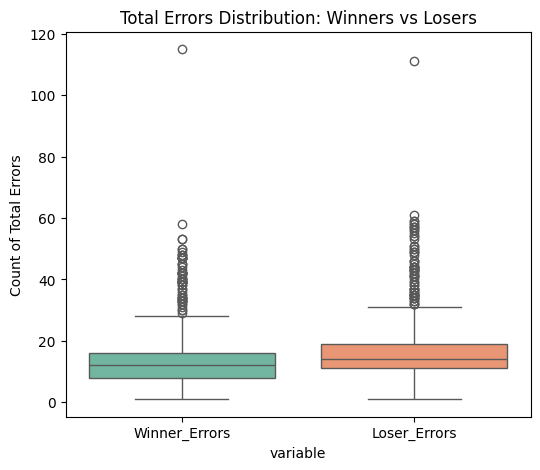

In [4]:
# Assign Errors to Winner vs Loser for comparison
df['Winner_Errors'] = np.where(df['Target'] == 1, df['TeamA_Errors'], df['TeamB_Errors'])
df['Loser_Errors']  = np.where(df['Target'] == 1, df['TeamB_Errors'], df['TeamA_Errors'])
clean_err = df[['Winner_Errors', 'Loser_Errors']].dropna()
better_team_wins = (clean_err['Winner_Errors'] < clean_err['Loser_Errors']).mean()

print(f"Matches won by the team with fewer {"Total Errors"}: {better_team_wins:.1%}")
print(f"Avg {"Total Errors"} - Winner: {clean_err['Winner_Errors'].mean():.1f}")
print(f"Avg {"Total Errors"} - Loser:  {clean_err['Loser_Errors'].mean():.1f}")

# Boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(data=clean_err.melt(), x='variable', y='value', palette='Set2')
plt.title(f'{"Total Errors"} Distribution: Winners vs Losers')
plt.ylabel(f'Count of {"Total Errors"}')
plt.savefig('eda_errors_boxplot.png')

One of the most important shots in pickleball is the 3rd shot.  It allows the offense to be able to move up to the kitchen, giving them a lot more ground.  If the 3rd shot is played correctly, it is very powerful in pickleball.  Here, we want to see the correlation of a successful third shot and winning the game. With a correlation of .562, a successful third shot is quite correlated with winning the game.  

In [5]:
p1_win = df.get('Player1_3rdShot_Win_Pct', 0)
p2_win = df.get('Player2_3rdShot_Win_Pct', 0)
p3_win = df.get('Player3_3rdShot_Win_Pct', 0)
p4_win = df.get('Player4_3rdShot_Win_Pct', 0)

# Calculate approx team success
df['TeamA_3rdShot_Success'] = p1_win + p2_win
df['TeamB_3rdShot_Success'] = p3_win + p4_win

# Correlation Check
corr_3rd = df['TeamA_3rdShot_Success'].corr(df['Target'])
print(f"Correlation (3rd Shot Success vs Winning): {corr_3rd:.3f}")

Correlation (3rd Shot Success vs Winning): 0.543


An upset happens when a lower DUPR rated Team wins against the higher rated DUPR team.  We can see in these upset matches the winning team had less errors than the winning team.  This shows how long rallies and drawing out errors from opponents can help win games.

In [6]:
upsets = df[df['Favored_Won'] == 0]

print(f"Total upsets in the dataset: {len(upsets)} matches")
print(f"Winner Errors: {upsets['Winner_Errors'].mean():.1f} Loser errors: {upsets['Loser_Errors'].mean():.1f} ")

Total upsets in the dataset: 488 matches
Winner Errors: 14.0 Loser errors: 17.0 


Now we will move onto some feature engineering. Let's make aggregate stats for each team.  

In [7]:
player_stats = ['Dinks', 'DinkErrors', 'Assists', 'UnforcedErrors', 'TotalShots']
for stat in player_stats:
    # Handle missing columns safely
    p1 = df.get(f'Player1_{stat}', 0)
    p2 = df.get(f'Player2_{stat}', 0)
    p3 = df.get(f'Player3_{stat}', 0)
    p4 = df.get(f'Player4_{stat}', 0)

    df[f'TeamA_{stat}'] = p1 + p2
    df[f'TeamB_{stat}'] = p3 + p4

These new columns look at the DUPR gap between the highest rated player and the lowest rated player.  A high gap means one strong player carrying a weaker one.

In [8]:
df['TeamA_Max_DUPR'] = df[['TeamAPlayer1_DUPR', 'TeamAPlayer2_DUPR']].max(axis=1)
df['TeamA_Min_DUPR'] = df[['TeamAPlayer1_DUPR', 'TeamAPlayer2_DUPR']].min(axis=1)
df['TeamA_Gap'] = df['TeamA_Max_DUPR'] - df['TeamA_Min_DUPR']

# Team B Gap
df['TeamB_Max_DUPR'] = df[['TeamBPlayer1_DUPR', 'TeamBPlayer2_DUPR']].max(axis=1)
df['TeamB_Min_DUPR'] = df[['TeamBPlayer1_DUPR', 'TeamBPlayer2_DUPR']].min(axis=1)
df['TeamB_Gap'] = df['TeamB_Max_DUPR'] - df['TeamB_Min_DUPR']

# The Differential: Does Team A have a bigger "weak link" problem than Team B?
df['Weak_Link_Diff'] = df['TeamA_Gap'] - df['TeamB_Gap']

This new column will see how aggressive teams play generally.  It measures the ratio between the total shots and how many of those are dinks.  This means that the rest of the shots are most likely drives aka aggresive plays.

In [9]:
for team in ['TeamA', 'TeamB']:
    total = df[f'{team}_TotalShots'] + 1
    dinks = df[f'{team}_Dinks']
    #(Total - Dinks) / Total
    df[f'{team}_Drive_Pct'] = (total - dinks) / total
df['Drive_Diff'] = df['TeamA_Drive_Pct'] - df['TeamB_Drive_Pct']

How well does the team play at the net?  This column will measure how many dinks a team makes and their dink error

In [10]:
df['TeamA_Net_Eff'] = df['TeamA_Dinks'] / (df['TeamA_DinkErrors'] + 1)
df['TeamB_Net_Eff'] = df['TeamB_Dinks'] / (df['TeamB_DinkErrors'] + 1)
df['Net_Efficiency_Diff'] = df['TeamA_Net_Eff'] - df['TeamB_Net_Eff']

Let's see how consistent players are as well based off their unforced errors and their total shots.

In [11]:
for team in ['TeamA', 'TeamB']:
    #Fill to 0 if column is NA
    errors = df[f'{team}_UnforcedErrors']
    shots = df[f'{team}_TotalShots'] + 1
    df[f'{team}_Consistency'] = 1 - (errors / shots)

df['Consistency_Diff'] = df['TeamA_Consistency'] - df['TeamB_Consistency']

Now let's try to split the dataset into different groups based on their playstyle.  In pickleball, there is a group of players that insist on driving towards the net rather than performing drops and dinking.  These are known as "bangers".  Through KMeans clustering, we can try to find which players are the "bangers".  Through the data we can see that there is a group that is dinking significantly more than the other groups.  They are also a higher DUPR score as well.

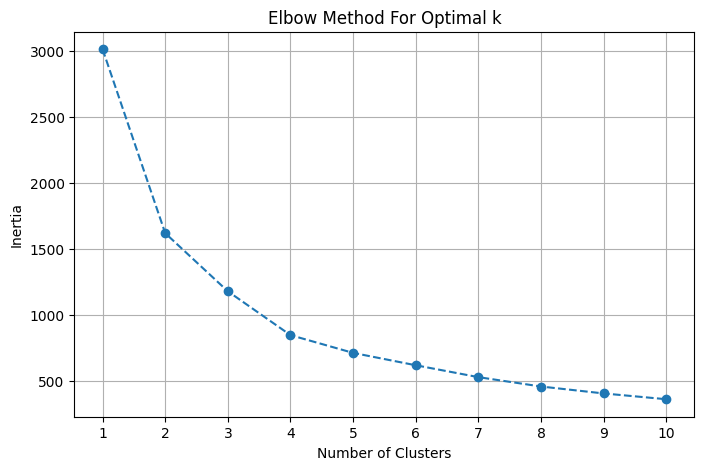

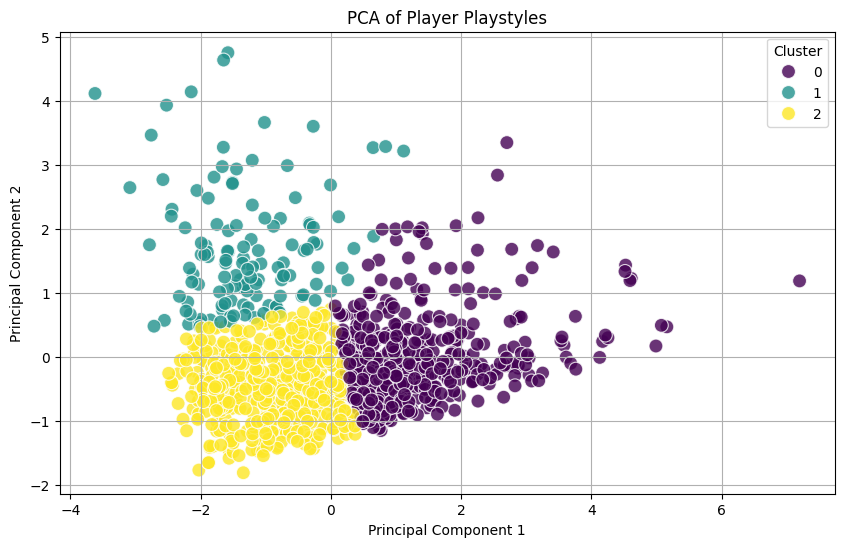

Average Stats per Playstyle Cluster:
                    DUPR  Dink_Pct  Hard_Hit_Pct  Error_Rate  TotalShots  \
Playstyle_Cluster                                                          
0                  5.127     0.273         0.727       0.031     402.078   
1                  4.327     0.124         0.876       0.101      94.882   
2                  4.470     0.104         0.896       0.038     393.827   

                   Total_Players  
Playstyle_Cluster                 
0                            427  
1                            125  
2                            452  

Dataset successfully saved to 'player_playstyles_complete.csv'


In [14]:
# Reshape data from match-level to player-level
p1_df = df[['TeamAPlayer1', 'TeamAPlayer1_DUPR', 'Player1_Dinks', 'Player1_TotalShots', 'Player1_UnforcedErrors']].copy()
p1_df.columns = ['PlayerName', 'DUPR', 'Dinks', 'TotalShots', 'UnforcedErrors']

p2_df = df[['TeamAPlayer2', 'TeamAPlayer2_DUPR', 'Player2_Dinks', 'Player2_TotalShots', 'Player2_UnforcedErrors']].copy()
p2_df.columns = ['PlayerName', 'DUPR', 'Dinks', 'TotalShots', 'UnforcedErrors']

p3_df = df[['TeamBPlayer1', 'TeamBPlayer1_DUPR', 'Player3_Dinks', 'Player3_TotalShots', 'Player3_UnforcedErrors']].copy()
p3_df.columns = ['PlayerName', 'DUPR', 'Dinks', 'TotalShots', 'UnforcedErrors']

p4_df = df[['TeamBPlayer2', 'TeamBPlayer2_DUPR', 'Player4_Dinks', 'Player4_TotalShots', 'Player4_UnforcedErrors']].copy()
p4_df.columns = ['PlayerName', 'DUPR', 'Dinks', 'TotalShots', 'UnforcedErrors']

player_matches = pd.concat([p1_df, p2_df, p3_df, p4_df], ignore_index=True)

# Calculate match-level rates
player_matches['TotalShots'] = player_matches['TotalShots'].replace(0, np.nan)
player_matches['Dink_Pct'] = player_matches['Dinks'] / player_matches['TotalShots']
player_matches['Hard_Hit_Pct'] = (player_matches['TotalShots'] - player_matches['Dinks']) / player_matches['TotalShots']
player_matches['Error_Rate'] = player_matches['UnforcedErrors'] / player_matches['TotalShots']

# Aggregate averages by player
player_stats = player_matches.groupby('PlayerName').agg({
    'DUPR': 'mean',
    'Dink_Pct': 'mean',
    'Hard_Hit_Pct': 'mean',
    'Error_Rate': 'mean',
    'TotalShots': 'sum'
}).reset_index()

# Handle Missing Values
player_stats['DUPR_Tier'] = player_stats['DUPR'].round(1)
metrics_to_fill = ['Dink_Pct', 'Hard_Hit_Pct', 'Error_Rate']

for col in metrics_to_fill:
    player_stats[col] = player_stats.groupby('DUPR_Tier')[col].transform(lambda x: x.fillna(x.mean()))
    player_stats[col] = player_stats[col].fillna(player_stats[col].mean())

player_stats = player_stats.drop(columns=['DUPR_Tier'])

# Scale the features
features = ['Dink_Pct', 'Hard_Hit_Pct', 'Error_Rate']
X = player_stats[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method Plot
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
player_stats['Playstyle_Cluster'] = kmeans.fit_predict(X_scaled)

# PCA Scatter Plot
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
player_stats['PCA1'] = principal_components[:, 0]
player_stats['PCA2'] = principal_components[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=player_stats,
    x='PCA1',
    y='PCA2',
    hue='Playstyle_Cluster',
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('PCA of Player Playstyles')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Print Average Stats per Group
cluster_averages = player_stats.groupby('Playstyle_Cluster').agg({
    'DUPR': 'mean',
    'Dink_Pct': 'mean',
    'Hard_Hit_Pct': 'mean',
    'Error_Rate': 'mean',
    'TotalShots': 'mean',
    'PlayerName': 'count'
}).rename(columns={'PlayerName': 'Total_Players'}).round(3)

print("Average Stats per Playstyle Cluster:")
print(cluster_averages)

# Save the Dataset
player_stats.to_csv('player_playstyles_complete.csv', index=False)
print("\nDataset successfully saved to 'player_playstyles_complete.csv'")

Now let's add these attributes onto the original dataset and save it for model evaluation!

In [15]:
playstyle_map = player_stats[['PlayerName', 'Playstyle_Cluster']]

player_columns = ['TeamAPlayer1', 'TeamAPlayer2', 'TeamBPlayer1', 'TeamBPlayer2']

for col in player_columns:
    temp_map = playstyle_map.rename(columns={
        'PlayerName': col,
        'Playstyle_Cluster': f'{col}_Playstyle'
    })

    df = df.merge(temp_map, on=col, how='left')

df.to_csv('matches_complete7.0.csv', index=False)
print("Saved playstyle dataset as matches_complete7.0.csv")

Saved playstyle dataset as matches_complete7.0.csv
